
# [`findcrack`](https://pypi.org/project/findcrack/) — Benchmarking and Visualization Template

This notebook benchmarks one or more `findcrack` models against one or more
datasets and reports the metrics/visuals appropriate for **crack segmentation**
specifically (thin, elongated, heavily class-imbalanced structures), not just
generic pixel accuracy.

**What's covered:**

| Category | Metrics / Visuals |
|---|---|
| Pixel-level | IoU, Dice, Precision, Recall, Pixel Accuracy *(via `findcrack.calculate_metrics`)* |
| Topology-aware | clDice (centerline Dice), Boundary IoU |
| Tolerance-based | Buffered Precision / Recall / F1 (ODS-style), Hausdorff distance, Average Surface Distance |
| Threshold sweep | Precision-Recall curve + Average Precision (AP), computed from probability maps |
| Qualitative | TP/FP/FN overlays (best/median/worst per model), skeleton (centerline) comparison |
| Stratified | Recall broken down by ground-truth crack width bucket |

**Expected dataset layout** (same convention as `findcrack`'s own training
template notebook):

```
<dataset_root>/
├── images/ 
|   └── test/   # e.g. img_0001.jpg, img_0002.png, ...
└── masks/
    └── test/   # e.g. img_0001.png, img_0002.png, ...  (same stem as the image)
```

Masks are treated as binary: any pixel value `> 0` is "crack" unless you set
`mask_positive_value` on a `DatasetSpec` (e.g. if your masks encode multiple
classes and cracks are a specific label).

Fill in the `CONFIGURATION` cell below with your model variants and dataset
paths, then run all cells.


In [1]:
# Cell 1: Imports and Setup

import os
import warnings
import tempfile
import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Tuple, Dict
import inspect

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
from sklearn.metrics import precision_recall_curve, average_precision_score

# findcrack specific imports
from findcrack import CrackInferencePipeline, load_model, list_models, calculate_metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Registered findcrack model variants:", list_models())

d:\codes\projects\interns\intern-year-four\crack\findcrack\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Registered findcrack model variants: ['Seg_YOLO26n-seg-v1_crack-seg']


## Configuration

In [2]:
# Cell 2: CONFIGURATION – change the lists and parameters below as needed

@dataclass
class ModelSpec:
    """One model to benchmark."""
    name: str
    variant: str          # name or URL passed to load_model()
    device: str = "cpu"
    patch_size: int = 512
    overlap_ratio: float = 0.2
    confidence_threshold: float = 0.5
    use_tta: bool = False
    local_checkpoint: bool = False
    extra_kwargs: dict = field(default_factory=dict)


@dataclass
class DatasetSpec:
    """One dataset to evaluate against. Expects `<root>/images` + `<root>/masks`."""
    name: str
    root: str
    image_ext: Tuple[str, ...] = (".jpg", ".jpeg", ".png")
    mask_ext: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp")
    mask_positive_value: Optional[int] = None   # None -> treat any value > 0 as "crack"


@dataclass
class BenchmarkConfig:
    models: List[ModelSpec]
    datasets: List[DatasetSpec]
    output_dir: str = "./benchmark_outputs"
    boundary_dilation_px: int = 2
    tolerance_px: int = 3
    width_buckets_px: Tuple[float, ...] = (0, 2, 4, 7, 1e6)
    pr_curve_pixel_sample: int = 20_000
    seed: int = 42

    def __post_init__(self):
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 3: EDIT THE FOLLOWING LISTS ACCORDING TO YOUR MODELS AND DATASETS

PROJECT_ROOT = r"" # for drive
COLAB_ROOT = r"" # for colab

DATASET_DIR = r"D:\codes\projects\interns\intern-year-four\crack\datasets"
ROOT_DIR = r"D:\codes\projects\interns\intern-year-four\crack\findcrack"
RELATIVE_MODEL_PATH = r"checkpoints\ultralytics\yolo\Seg_YOLO26n-seg-v2_crack-seg\weights\Seg_YOLO26n-seg-v2_crack-seg_best.onnx"
YOLO26_seg_v2_crack_seg = os.path.join(ROOT_DIR, RELATIVE_MODEL_PATH)

MODEL_LIST = [
    ModelSpec(name="YOLO26_seg_v2_crack_seg", variant=YOLO26_seg_v2_crack_seg, device="cpu", local_checkpoint=True),
]

DATASET_LIST = [
    
    DatasetSpec(name="CFD", root=f"{DATASET_DIR}/CFD"),
    DatasetSpec(name="CrackTree260", root=f"{DATASET_DIR}/CrackTree260"),
]

# Global parameters – these are also editable
BENCHMARK_PARAMS = {
    "output_dir": f"./benchmark_outputs_{time.strftime('%Y-%m-%d_%H-%M-%S')}",
    "boundary_dilation_px": 2,
    "tolerance_px": 3,
    "width_buckets_px": (0, 2, 4, 7, 1e6),
    "pr_curve_pixel_sample": 20_000,
    "seed": 42,
}

# Instantiate the configuration
config = BenchmarkConfig(
    models=MODEL_LIST,
    datasets=DATASET_LIST,
    **BENCHMARK_PARAMS
)

np.random.seed(config.seed)
print(f"{len(config.models)} model(s) × {len(config.datasets)} dataset(s) configured.")

1 model(s) × 2 dataset(s) configured.


In [4]:
# Cell 3: Helper Functions (dataset discovery, loading, metrics, padding)

# ---------- dataset discovery ----------
def find_files(root_dir, extensions):
    files = []
    for ext in extensions:
        files.extend(Path(root_dir).rglob(f"*{ext}"))
        files.extend(Path(root_dir).rglob(f"*{ext.upper()}"))
    return sorted(set(files))

def discover_pairs(ds: DatasetSpec):
    root = Path(ds.root)
    images_dir = root / "images/test" if (root / "images/test").exists() else root / "images"
    masks_dir = root / "masks/test" if (root / "masks/test").exists() else root / "masks"
    images = find_files(images_dir, ds.image_ext)
    pairs = []
    for img_path in images:
        stem = img_path.stem
        candidates = [p for p in Path(masks_dir).rglob(f"{stem}.*") if p.suffix.lower() in ds.mask_ext]
        if candidates:
            pairs.append((img_path, candidates[0]))
        else:
            print(f"[{ds.name}] Warning: no mask found for {img_path.name}, skipping.")
    print(f"[{ds.name}] Found {len(pairs)} image/mask pairs.")
    return pairs

def load_gt_mask(mask_path, positive_value=None, shape=None) -> np.ndarray:
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m.ndim == 3:
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    binary = (m == positive_value) if positive_value is not None else (m > 0)
    if shape is not None and binary.shape != tuple(shape):
        binary = cv2.resize(
            binary.astype(np.uint8), (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST
        ).astype(bool)
    return binary

def predict_with_auto_padding(img_path, pipeline, target_size=512):
    """Run inference on image; pad if smaller than target_size."""
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    if h >= target_size and w >= target_size:
        return pipeline.predict(str(img_path))
    new_h = max(h, target_size)
    new_w = max(w, target_size)
    pad_top = (new_h - h) // 2
    pad_bottom = new_h - h - pad_top
    pad_left = (new_w - w) // 2
    pad_right = new_w - w - pad_left
    padded_img = cv2.copyMakeBorder(
        img, pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp_file:
        temp_path = tmp_file.name
        cv2.imwrite(temp_path, padded_img)
    try:
        result = pipeline.predict(temp_path)
        result["binary_mask"] = result["binary_mask"][pad_top:pad_top+h, pad_left:pad_left+w]
        result["confidence_map"] = result["confidence_map"][pad_top:pad_top+h, pad_left:pad_left+w]
        return result
    finally:
        os.unlink(temp_path)

def _slug(name: str) -> str:
    return "".join(c if c.isalnum() else "_" for c in name).strip("_")

# ---------- extended metrics ----------
def _boundary_band(mask: np.ndarray, band_px: int) -> np.ndarray:
    mask_u8 = mask.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(mask_u8, kernel, iterations=max(band_px, 1))
    return (mask_u8 - eroded).astype(bool)

def boundary_iou(y_true: np.ndarray, y_pred: np.ndarray, band_px: int = 2, epsilon: float = 1e-7) -> float:
    gt_b = _boundary_band(y_true, band_px)
    pred_b = _boundary_band(y_pred, band_px)
    intersection = np.logical_and(gt_b, pred_b).sum()
    union = np.logical_or(gt_b, pred_b).sum()
    return float(intersection / (union + epsilon))

def _skeleton(mask: np.ndarray) -> np.ndarray:
    return skeletonize(mask.astype(bool))

def cl_dice(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-7) -> float:
    if y_true.sum() == 0 and y_pred.sum() == 0:
        return 1.0
    skel_true = _skeleton(y_true)
    skel_pred = _skeleton(y_pred)
    t_prec = (skel_pred & y_true).sum() / (skel_pred.sum() + epsilon)
    t_sens = (skel_true & y_pred).sum() / (skel_true.sum() + epsilon)
    return float(2 * t_prec * t_sens / (t_prec + t_sens + epsilon))

def tolerance_prf(y_true: np.ndarray, y_pred: np.ndarray, tolerance_px: int = 3, epsilon: float = 1e-7) -> dict:
    if y_true.sum() == 0 and y_pred.sum() == 0:
        return {"Tol_Precision": 1.0, "Tol_Recall": 1.0, "Tol_F1": 1.0}
    dist_from_gt = distance_transform_edt(~y_true)
    dist_from_pred = distance_transform_edt(~y_pred)
    precision = float((dist_from_gt[y_pred] <= tolerance_px).sum() / (y_pred.sum() + epsilon)) if y_pred.sum() > 0 else 0.0
    recall = float((dist_from_pred[y_true] <= tolerance_px).sum() / (y_true.sum() + epsilon)) if y_true.sum() > 0 else 1.0
    f1 = 2 * precision * recall / (precision + recall + epsilon)
    return {"Tol_Precision": precision, "Tol_Recall": recall, "Tol_F1": f1}

def hausdorff_and_asd(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    if y_true.sum() == 0 or y_pred.sum() == 0:
        return {"Hausdorff": np.nan, "ASD": np.nan}
    dist_from_gt = distance_transform_edt(~y_true)
    dist_from_pred = distance_transform_edt(~y_pred)
    d_pred_to_gt = dist_from_gt[y_pred]
    d_gt_to_pred = dist_from_pred[y_true]
    hausdorff = float(max(d_pred_to_gt.max(), d_gt_to_pred.max()))
    asd = float((d_pred_to_gt.sum() + d_gt_to_pred.sum()) / (y_pred.sum() + y_true.sum()))
    return {"Hausdorff": hausdorff, "ASD": asd}

def estimate_mean_crack_width(y_true: np.ndarray) -> float:
    if y_true.sum() == 0:
        return np.nan
    skel = _skeleton(y_true)
    if skel.sum() == 0:
        return np.nan
    dist = distance_transform_edt(y_true)
    return float(2 * dist[skel].mean())

def compute_all_metrics(y_true: np.ndarray, y_pred_binary: np.ndarray, cfg: BenchmarkConfig) -> dict:
    metrics = calculate_metrics(y_true, y_pred_binary)
    metrics["Boundary_IoU"] = boundary_iou(y_true, y_pred_binary, cfg.boundary_dilation_px)
    metrics["clDice"] = cl_dice(y_true, y_pred_binary)
    metrics.update(tolerance_prf(y_true, y_pred_binary, cfg.tolerance_px))
    metrics.update(hausdorff_and_asd(y_true, y_pred_binary))
    metrics["GT_Crack_Width_px"] = estimate_mean_crack_width(y_true)
    metrics["GT_Positive_Pixels"] = int(y_true.sum())
    metrics["Pred_Positive_Pixels"] = int(y_pred_binary.sum())
    return metrics

# ---------- pipeline builder ----------
LOAD_MODEL_PARAMS = set(inspect.signature(load_model).parameters)

def build_pipeline(model_spec: ModelSpec) -> CrackInferencePipeline:
    load_kwargs = {"device": model_spec.device}
    if "local_checkpoint" in LOAD_MODEL_PARAMS:
        load_kwargs["local_checkpoint"] = model_spec.local_checkpoint
    elif model_spec.local_checkpoint:
        warnings.warn("Installed findcrack does not support local_checkpoint; ignoring.")
    model = load_model(model_spec.variant, **load_kwargs)
    return CrackInferencePipeline(
        model=model,
        device=model_spec.device,
        patch_size=model_spec.patch_size,
        overlap_ratio=model_spec.overlap_ratio,
        confidence_threshold=model_spec.confidence_threshold,
        use_tta=model_spec.use_tta,
        **model_spec.extra_kwargs,
    )

In [5]:
# Cell 4: Benchmark Runner (with timing)

def run_benchmark(cfg: BenchmarkConfig):
    rows = []
    pr_curve_store = {}  # key: (model_name, dataset_name) -> {"y_true":[], "y_score":[]}
    
    for model_spec in cfg.models:
        print(f"\n== Loading model: {model_spec.name} ({model_spec.variant}) ==")
        pipeline = build_pipeline(model_spec)
        
        for ds in cfg.datasets:
            pairs = discover_pairs(ds)
            pred_dir = Path(cfg.output_dir) / "predictions" / _slug(model_spec.name) / _slug(ds.name)
            pred_dir.mkdir(parents=True, exist_ok=True)
            key = (model_spec.name, ds.name)
            pr_curve_store.setdefault(key, {"y_true": [], "y_score": []})
            
            for img_path, mask_path in tqdm(pairs, desc=f"{model_spec.name} / {ds.name}"):
                try:
                    # ---- inference ----
                    t0 = time.perf_counter()
                    result = predict_with_auto_padding(img_path, pipeline, target_size=model_spec.patch_size)
                    infer_time = time.perf_counter() - t0
                    
                    pred_binary = result["binary_mask"].astype(bool)
                    gt_binary = load_gt_mask(mask_path, ds.mask_positive_value, shape=pred_binary.shape)
                    
                    # ---- metrics ----
                    t0 = time.perf_counter()
                    metrics = compute_all_metrics(gt_binary, pred_binary, cfg)
                    metric_time = time.perf_counter() - t0
                    
                    # store times
                    metrics["inference_time_s"] = infer_time
                    metrics["metric_time_s"] = metric_time
                    metrics["total_time_s"] = infer_time + metric_time
                except Exception as e:
                    print(f" Skipping {img_path.name}: inference failed ({e})")
                    continue
                
                # save prediction mask
                pred_mask_path = pred_dir / f"{img_path.stem}_pred.png"
                cv2.imwrite(str(pred_mask_path), result["binary_mask"])
                
                # store metadata
                metrics.update({
                    "model": model_spec.name,
                    "dataset": ds.name,
                    "image": img_path.name,
                    "image_path": str(img_path),
                    "mask_path": str(mask_path),
                    "pred_mask_path": str(pred_mask_path),
                })
                rows.append(metrics)
                
                # sample pixels for PR curve (if confidence_map exists)
                conf = result["confidence_map"].ravel()
                gt_flat = gt_binary.ravel()
                n_pixels = conf.size
                if n_pixels > cfg.pr_curve_pixel_sample:
                    idx = np.random.choice(n_pixels, cfg.pr_curve_pixel_sample, replace=False)
                    pr_curve_store[key]["y_true"].extend(gt_flat[idx])
                    pr_curve_store[key]["y_score"].extend(conf[idx])
                else:
                    pr_curve_store[key]["y_true"].extend(gt_flat)
                    pr_curve_store[key]["y_score"].extend(conf)
    
    # convert to DataFrame
    results_df = pd.DataFrame(rows)
    # convert list columns to arrays for PR store
    for k in pr_curve_store:
        pr_curve_store[k]["y_true"] = np.array(pr_curve_store[k]["y_true"])
        pr_curve_store[k]["y_score"] = np.array(pr_curve_store[k]["y_score"])
    return results_df, pr_curve_store

In [6]:
# Cell 5: Run the Benchmark

results_df, pr_curve_store = run_benchmark(config)
print(f"Saved per-image metrics to {Path(config.output_dir) / 'per_image_metrics.csv'}")
results_df.to_csv(Path(config.output_dir) / "per_image_metrics.csv", index=False)
results_df.head()


== Loading model: YOLO26_seg_v2_crack_seg (D:\codes\projects\interns\intern-year-four\crack\findcrack\checkpoints\ultralytics\yolo\Seg_YOLO26n-seg-v2_crack-seg\weights\Seg_YOLO26n-seg-v2_crack-seg_best.onnx) ==
[CFD] Warning: no mask found for 001_1_mask.png, skipping.
[CFD] Warning: no mask found for 001_1_overlay.png, skipping.
[CFD] Warning: no mask found for 001_1_vis.png, skipping.
[CFD] Warning: no mask found for 001__1_mask.png, skipping.
[CFD] Warning: no mask found for 001__1_overlay.png, skipping.
[CFD] Warning: no mask found for 001__1_vis.png, skipping.
[CFD] Warning: no mask found for 001_mask.png, skipping.
[CFD] Warning: no mask found for 001_overlay.png, skipping.
[CFD] Warning: no mask found for 001_vis.png, skipping.
[CFD] Warning: no mask found for 001add1_mask.png, skipping.
[CFD] Warning: no mask found for 001add1_overlay.png, skipping.
[CFD] Warning: no mask found for 001add1_vis.png, skipping.
[CFD] Warning: no mask found for 001adjust1_mask.png, skipping.
[CFD]

YOLO26_seg_v2_crack_seg / CFD: 100%|██████████| 73/73 [00:17<00:00,  4.27it/s]


[CrackTree260] Found 39 image/mask pairs.


YOLO26_seg_v2_crack_seg / CrackTree260: 100%|██████████| 39/39 [00:26<00:00,  1.47it/s]


Saved per-image metrics to benchmark_outputs_2026-07-31_14-35-31\per_image_metrics.csv


,IoU,Dice,Precision,Recall,Pixel Accuracy,Boundary_IoU,clDice,Tol_Precision,Tol_Recall,Tol_F1,...,Pred_Positive_Pixels,inference_time_s,metric_time_s,total_time_s,model,dataset,image,image_path,mask_path,pred_mask_path
0,0.487361,0.655337,0.528056,0.863463,0.989173,0.294843,0.886739,0.990648,0.925177,0.956794,...,2994,0.257556,0.074611,0.332167,YOLO26_seg_v2_crack_seg,CFD,001.jpg,D:\codes\projects\interns\intern-year-four\cra...,D:\codes\projects\interns\intern-year-four\cra...,benchmark_outputs_2026-07-31_14-35-31\predicti...
1,0.424589,0.596086,0.524481,0.690333,0.988848,0.303861,0.709443,0.973444,0.791371,0.873015,...,2410,0.121709,0.072761,0.194470,YOLO26_seg_v2_crack_seg,CFD,001_1.jpg,D:\codes\projects\interns\intern-year-four\cra...,D:\codes\projects\interns\intern-year-four\cra...,benchmark_outputs_2026-07-31_14-35-31\predicti...
2,0.514657,0.679569,0.568851,0.843801,0.990514,0.355005,0.879263,0.992268,0.925724,0.957841,...,2716,0.112475,0.073913,0.186388,YOLO26_seg_v2_crack_seg,CFD,001__1.jpg,D:\codes\projects\interns\intern-year-four\cra...,D:\codes\projects\interns\intern-year-four\cra...,benchmark_outputs_2026-07-31_14-35-31\predicti...
3,0.495618,0.662760,0.525978,0.895685,0.989134,0.295144,0.900933,0.993586,0.948116,0.970318,...,3118,0.097084,0.074623,0.171707,YOLO26_seg_v2_crack_seg,CFD,001add1.jpg,D:\codes\projects\interns\intern-year-four\cra...,D:\codes\projects\interns\intern-year-four\cra...,benchmark_outputs_2026-07-31_14-35-31\predicti...
4,0.078938,0.146326,0.103692,0.248498,0.965436,0.050286,0.197508,0.248633,0.353905,0.292072,...,4388,0.160600,0.051597,0.212197,YOLO26_seg_v2_crack_seg,CFD,001adjust1.jpg,D:\codes\projects\interns\intern-year-four\cra...,D:\codes\projects\interns\intern-year-four\cra...,benchmark_outputs_2026-07-31_14-35-31\predicti...


In [7]:
# Cell 6: Summary Table (mean ± std, including timing)

metric_cols = [
    "IoU", "Dice", "Precision", "Recall", "Pixel Accuracy",
    "Boundary_IoU", "clDice", "Tol_Precision", "Tol_Recall", "Tol_F1",
    "Hausdorff", "ASD",
    "inference_time_s", "metric_time_s", "total_time_s"
]
summary = results_df.groupby(["model", "dataset"])[metric_cols].agg(["mean", "std"]).round(4)
summary.to_csv(Path(config.output_dir) / "summary_metrics.csv")
summary

IoU            Dice          \
                                        mean     std    mean     std   
model                   dataset                                        
YOLO26_seg_v2_crack_seg CFD           0.3109  0.1563  0.4500  0.2078   
                        CrackTree260  0.0198  0.0139  0.0385  0.0264   

                                     Precision          Recall          \
                                          mean     std    mean     std   
model                   dataset                                          
YOLO26_seg_v2_crack_seg CFD             0.4048  0.1835  0.5918  0.2970   
                        CrackTree260    0.0423  0.0316  0.0577  0.0489   

                                     Pixel Accuracy          ... Hausdorff  \
                                               mean     std  ...      mean   
model                   dataset                              ...             
YOLO26_seg_v2_crack_seg CFD                  0.9753  0.0223  ...   83.0765   
                        CrackTree260         0.9888  0.0066  ...  387.7995   

                                                    ASD           \
                                          std      mean      std   
model                   dataset                                    
YOLO26_seg_v2_crack_seg CFD           78.0878   16.9372  28.6237   
                        CrackTree260  96.2648  129.2647  60.2554   

                                     inference_time_s         metric_time_s  \
                                                 mean     std          mean   
model                   dataset                                               
YOLO26_seg_v2_crack_seg CFD                    0.1335  0.0421        0.0778   
                        CrackTree260           0.4164  0.1089        0.2199   

                                             total_time_s          
                                         std         mean     std  
model                   dataset                                    
YOLO26_seg_v2_crack_seg CFD           0.0140       0.2113  0.0426  
                        CrackTree260  0.0387       0.6363  0.1359  

[2 rows x 30 columns]

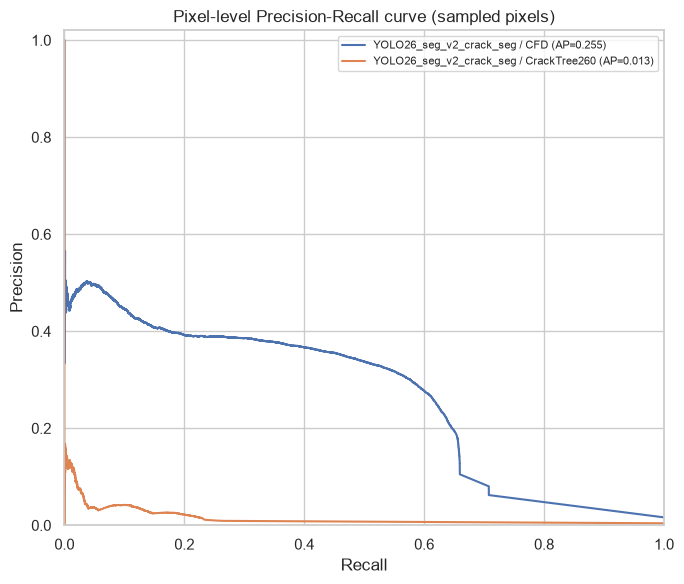

,model,dataset,AP
0,YOLO26_seg_v2_crack_seg,CFD,0.254783
1,YOLO26_seg_v2_crack_seg,CrackTree260,0.012850


In [8]:
# Cell 7: Precision‑Recall Curves + Average Precision (AP)

def plot_pr_curves(pr_curve_store: dict, output_dir: str) -> pd.DataFrame:
    fig, ax = plt.subplots(figsize=(7, 6))
    ap_rows = []
    for (model_name, ds_name), data in pr_curve_store.items():
        y_true = data["y_true"]
        y_score = data["y_score"]
        if y_true.sum() == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        ap_rows.append({"model": model_name, "dataset": ds_name, "AP": ap})
        ax.plot(recall, precision, label=f"{model_name} / {ds_name} (AP={ap:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Pixel-level Precision-Recall curve (sampled pixels)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(Path(output_dir) / "pr_curves.png", dpi=150)
    plt.show()
    return pd.DataFrame(ap_rows)

ap_df = plot_pr_curves(pr_curve_store, config.output_dir)
ap_df

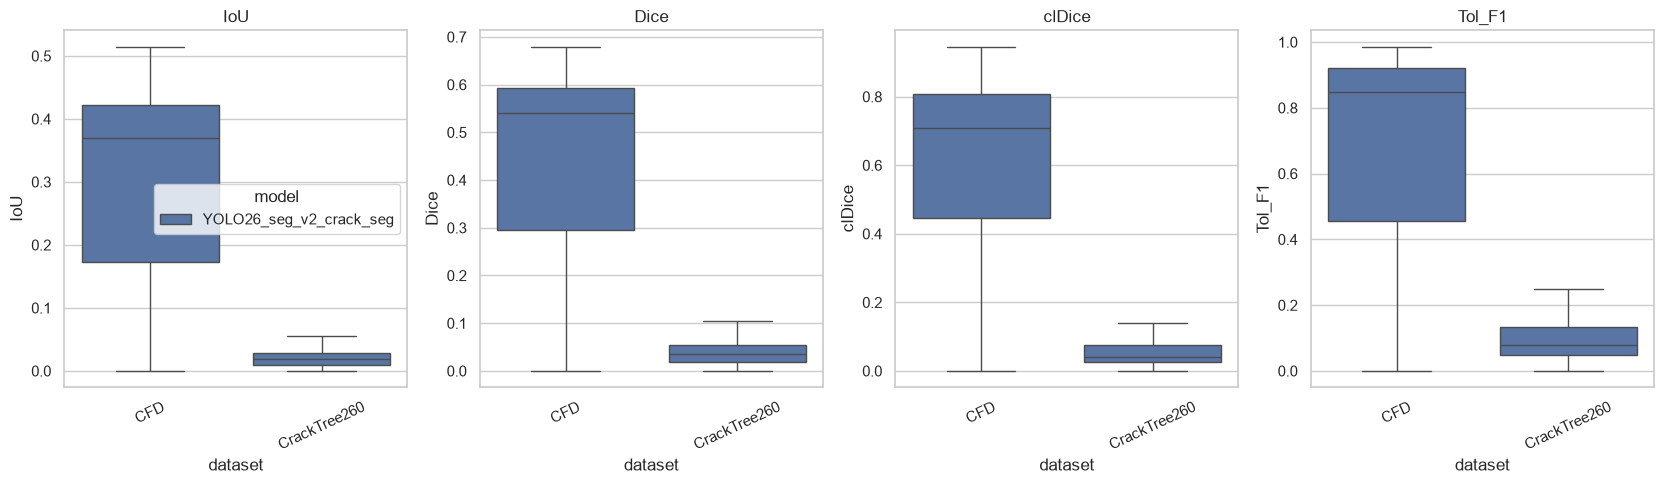

In [9]:
# Cell 8: Metric Distributions (Boxplots)

def plot_metric_distributions(results_df: pd.DataFrame, metrics_to_plot: list, output_dir: str):
    n = len(metrics_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 5))
    axes = np.atleast_1d(axes)
    for i, (ax, metric) in enumerate(zip(axes, metrics_to_plot)):
        sns.boxplot(data=results_df, x="dataset", y=metric, hue="model", ax=ax)
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=25)
        if i > 0 and ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.tight_layout()
    fig.savefig(Path(output_dir) / "metric_distributions.png", dpi=150)
    plt.show()

plot_metric_distributions(results_df, ["IoU", "Dice", "clDice", "Tol_F1"], config.output_dir)

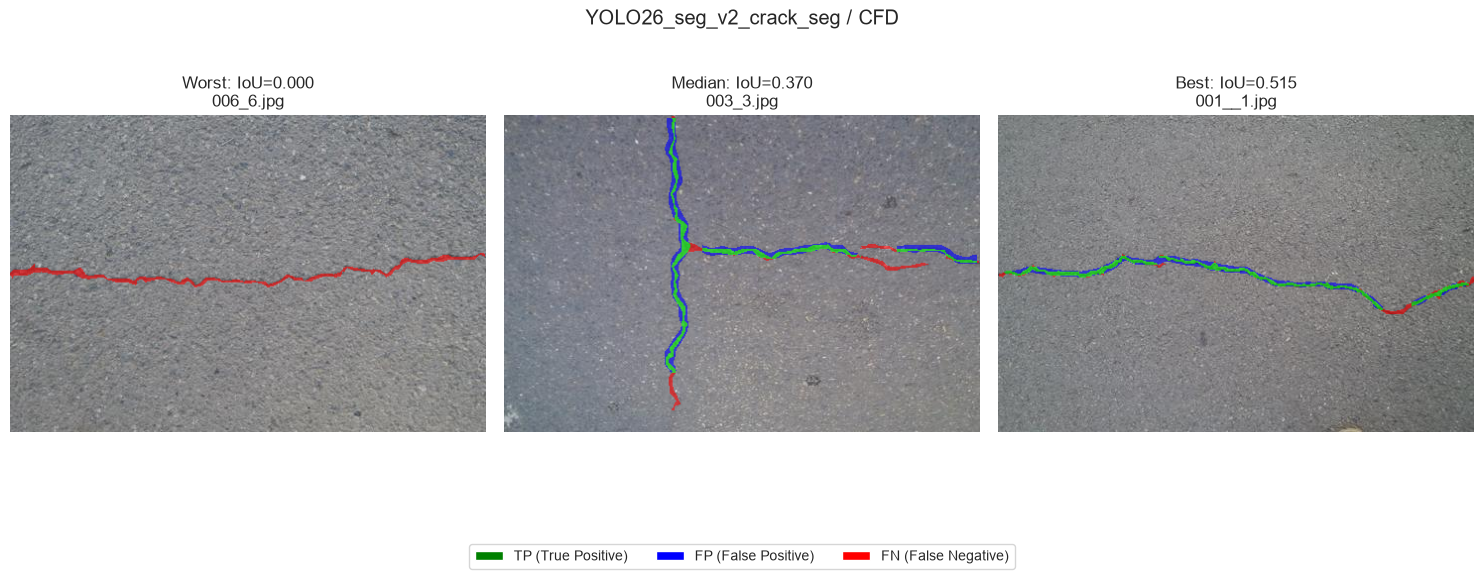

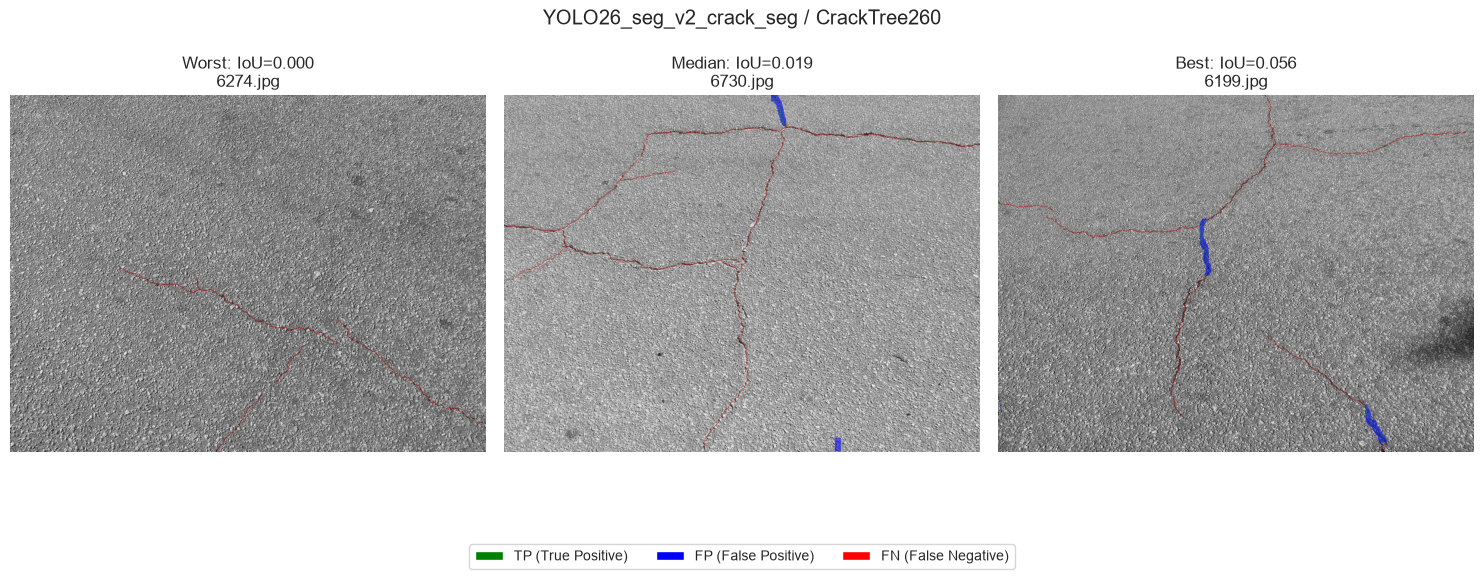

In [10]:
# Cell 9: Qualitative Overlays (TP/FP/FN)

def tp_fp_fn_overlay(image: np.ndarray, gt: np.ndarray, pred: np.ndarray, alpha: float = 0.6) -> np.ndarray:
    overlay = image.copy()
    overlay[gt & pred] = [0, 255, 0]          # TP - Green
    overlay[~gt & pred] = [0, 0, 255]       # FP - Yellow (changed from red)
    overlay[gt & ~pred] = [255, 0, 0]         # FN - Red (changed from blue)
    return cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

def show_qualitative_examples(results_df: pd.DataFrame, config: BenchmarkConfig, metric: str = "IoU"):
    for (model_name, ds_name), group in results_df.groupby(["model", "dataset"]):
        sorted_group = group.sort_values(metric).reset_index(drop=True)
        picks = {"Worst": 0, "Median": len(sorted_group)//2, "Best": len(sorted_group)-1}
        
        # Create figure with extra space at bottom for legend
        fig, axes = plt.subplots(1, len(picks), figsize=(5*len(picks), 5.5))
        if len(picks) == 1:
            axes = [axes]
        
        for ax, (label, i) in zip(axes, picks.items()):
            row = sorted_group.iloc[i]
            image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
            gt = load_gt_mask(row["mask_path"], shape=image.shape[:2])
            pred = cv2.imread(row["pred_mask_path"], cv2.IMREAD_GRAYSCALE) > 0
            if pred.shape != image.shape[:2]:
                pred = cv2.resize(pred.astype(np.uint8), (image.shape[1], image.shape[0]),
                                  interpolation=cv2.INTER_NEAREST).astype(bool)
            ax.imshow(tp_fp_fn_overlay(image, gt, pred))
            ax.set_title(f"{label}: {metric}={row[metric]:.3f}\n{row['image']}")
            ax.axis("off")
        
        # Add global legend at the bottom with updated colors
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', label='TP (True Positive)'),
            Patch(facecolor='blue', label='FP (False Positive)'),  # Updated
            Patch(facecolor='red', label='FN (False Negative)')      # Updated
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
                  fontsize=10, bbox_to_anchor=(0.5, -0.05))
        
        fig.suptitle(f"{model_name} / {ds_name}")
        fig.tight_layout()
        plt.subplots_adjust(bottom=0.1)
        fig.savefig(Path(config.output_dir) / f"qualitative_{_slug(model_name)}_{_slug(ds_name)}.png", 
                   dpi=150, bbox_inches='tight')
        plt.show()

show_qualitative_examples(results_df, config, metric="IoU")

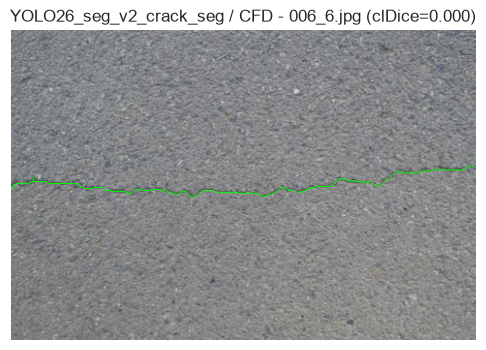

In [11]:
# Cell 10: Skeleton (Centerline) Comparison

def plot_skeleton_comparison(image_path: str, mask_path: str, pred_mask_path: str, title: str = ""):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    gt = load_gt_mask(mask_path, shape=image.shape[:2])
    pred = cv2.imread(pred_mask_path, cv2.IMREAD_GRAYSCALE) > 0
    if pred.shape != gt.shape:
        pred = cv2.resize(pred.astype(np.uint8), (gt.shape[1], gt.shape[0]),
                          interpolation=cv2.INTER_NEAREST).astype(bool)
    skel_gt = _skeleton(gt)
    skel_pred = _skeleton(pred)
    canvas = image.copy()
    canvas[skel_gt] = [0, 255, 0]               # GT in green
    canvas[skel_pred] = [255, 0, 255]           # pred in magenta
    canvas[skel_gt & skel_pred] = [255, 255, 0] # overlap in yellow
    plt.figure(figsize=(6,6))
    plt.imshow(canvas)
    plt.title(title or "Skeleton comparison (green=GT, magenta=pred, yellow=overlap)")
    plt.axis("off")
    plt.show()

# Example: pick the image with worst clDice
worst_row = results_df.sort_values("clDice").iloc[0]
plot_skeleton_comparison(
    worst_row["image_path"],
    worst_row["mask_path"],
    worst_row["pred_mask_path"],
    title=f"{worst_row['model']} / {worst_row['dataset']} - {worst_row['image']} (clDice={worst_row['clDice']:.3f})"
)

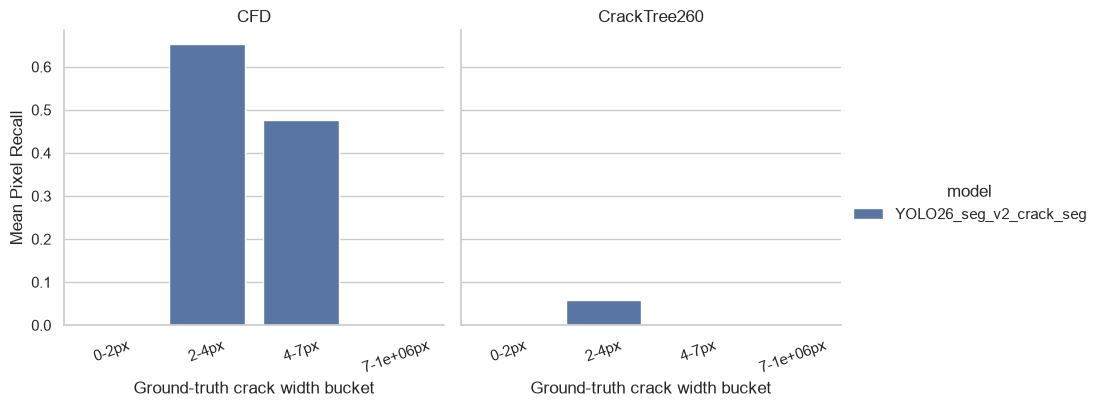

,model,dataset,width_bucket,Recall
0,YOLO26_seg_v2_crack_seg,CFD,2-4px,0.652026
1,YOLO26_seg_v2_crack_seg,CFD,4-7px,0.476175
2,YOLO26_seg_v2_crack_seg,CrackTree260,2-4px,0.057696


In [12]:
# Cell 11: Recall Stratified by Ground‑Truth Crack Width

def bucket_recall_by_width(results_df: pd.DataFrame, cfg: BenchmarkConfig) -> pd.DataFrame:
    bins = list(cfg.width_buckets_px)
    labels = [f"{bins[i]:g}-{bins[i+1]:g}px" for i in range(len(bins)-1)]
    df = results_df.dropna(subset=["GT_Crack_Width_px"]).copy()
    df["width_bucket"] = pd.cut(df["GT_Crack_Width_px"], bins=bins, labels=labels, right=False)
    summary = df.groupby(["model", "dataset", "width_bucket"], observed=True)["Recall"].mean().reset_index()
    g = sns.catplot(
        data=summary, x="width_bucket", y="Recall", hue="model", col="dataset",
        kind="bar", height=4, aspect=1.1,
    )
    g.set_axis_labels("Ground-truth crack width bucket", "Mean Pixel Recall")
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=20)
    g.savefig(Path(cfg.output_dir) / "recall_by_crack_width.png", dpi=150)
    plt.show()
    return summary

width_summary = bucket_recall_by_width(results_df, config)
width_summary


--- Generating Heatmap ---
Heatmap saved to benchmark_outputs_2026-07-31_14-35-31\heatmap_metrics.png


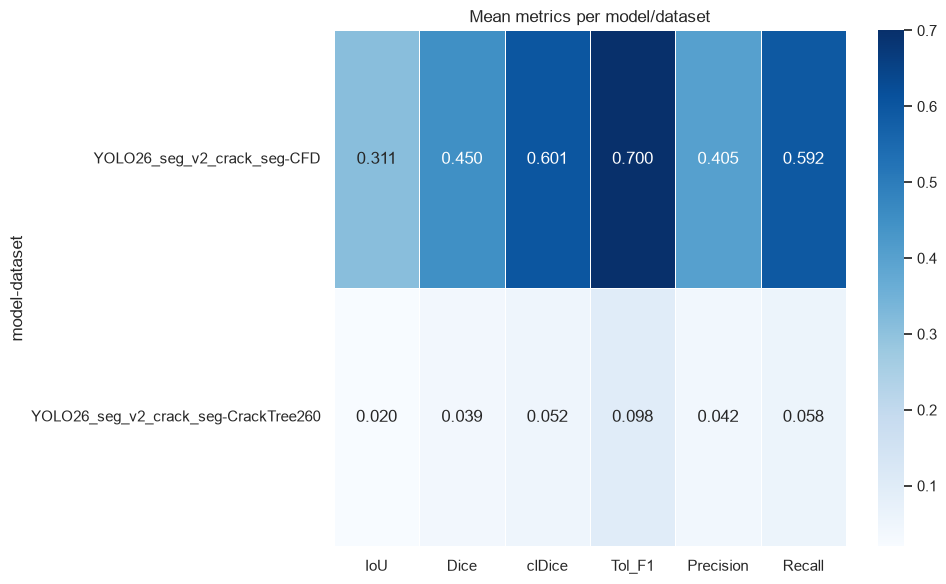


--- Generating Radar Chart ---
Radar chart saved to benchmark_outputs_2026-07-31_14-35-31\radar_chart.png


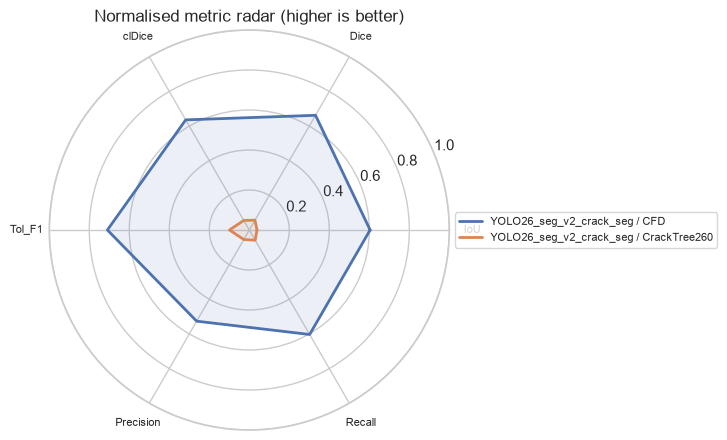


--- Generating Speed-Accuracy Trade-off Plot ---
Trade-off plot saved to benchmark_outputs_2026-07-31_14-35-31\iou_vs_time.png


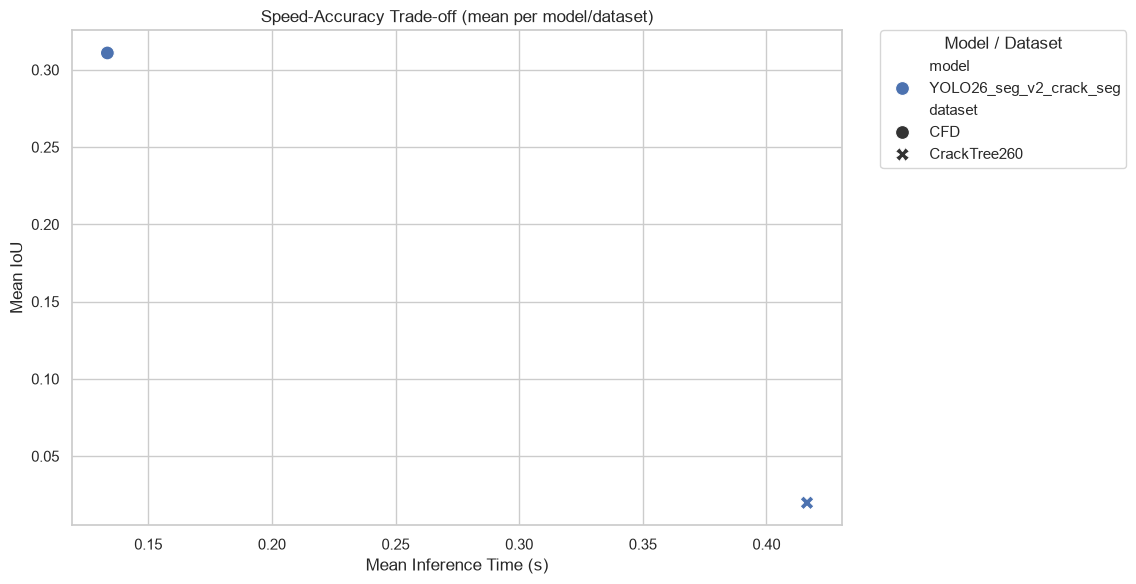


--- Generating Correlation Matrix ---
Correlation matrix saved to benchmark_outputs_2026-07-31_14-35-31\correlation_matrix.png


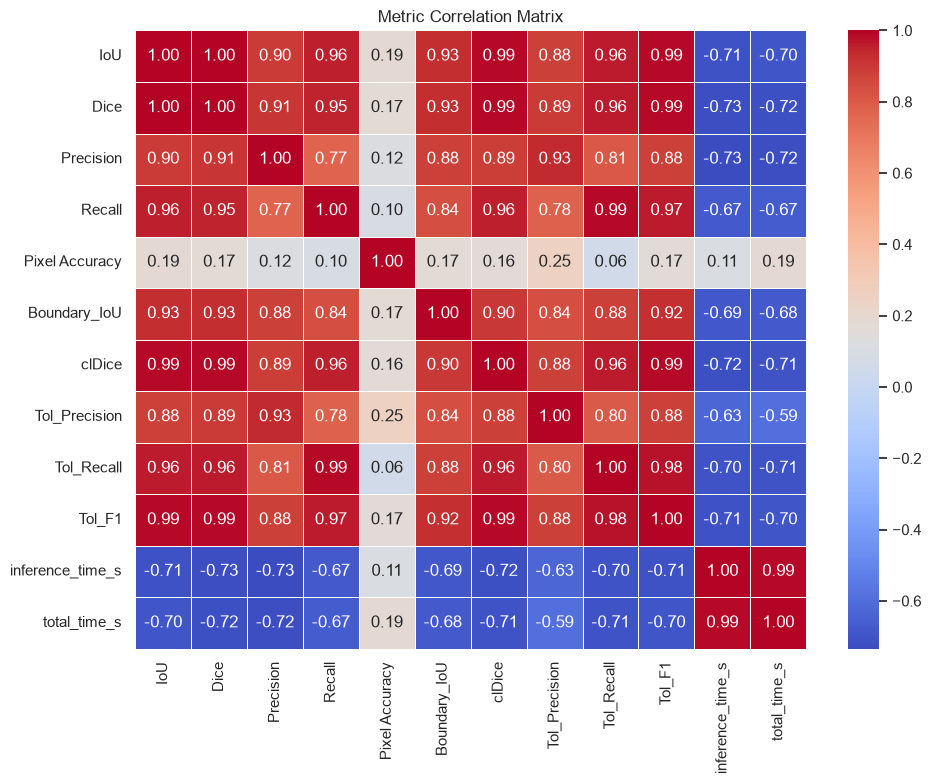

,IoU,Dice,Precision,Recall,Pixel Accuracy,Boundary_IoU,clDice,Tol_Precision,Tol_Recall,Tol_F1,inference_time_s,total_time_s
IoU,1.000000,0.997578,0.895077,0.955630,0.186322,0.928893,0.989332,0.879585,0.964006,0.988535,-0.711213,-0.700335
Dice,0.997578,1.000000,0.910886,0.949944,0.167499,0.931147,0.990882,0.894581,0.963302,0.992617,-0.725349,-0.715537
Precision,0.895077,0.910886,1.000000,0.771914,0.116493,0.883943,0.885966,0.934577,0.806412,0.880448,-0.734338,-0.721126
Recall,0.955630,0.949944,0.771914,1.000000,0.095419,0.841870,0.958098,0.782076,0.989487,0.965599,-0.673629,-0.672469
Pixel Accuracy,0.186322,0.167499,0.116493,0.095419,1.000000,0.172576,0.160177,0.251654,0.057221,0.165527,0.107020,0.185140
Boundary_IoU,0.928893,0.931147,0.883943,0.841870,0.172576,1.000000,0.899412,0.838411,0.881655,0.919518,-0.687326,-0.679000
clDice,0.989332,0.990882,0.885966,0.958098,0.160177,0.899412,1.000000,0.880656,0.963306,0.988561,-0.715160,-0.705347
Tol_Precision,0.879585,0.894581,0.934577,0.782076,0.251654,0.838411,0.880656,1.000000,0.797932,0.878760,-0.627450,-0.593063
Tol_Recall,0.964006,0.963302,0.806412,0.989487,0.057221,0.881655,0.963306,0.797932,1.000000,0.979255,-0.703097,-0.706944
Tol_F1,0.988535,0.992617,0.880448,0.965599,0.165527,0.919518,0.988561,0.878760,0.979255,1.000000,-0.707558,-0.699676


In [13]:
# Cell 12: Additional Visualisations (Heatmap, Radar, Trade‑off, Correlation)

def plot_heatmap(df, metrics=None, output_dir=None):
    """
    Create a heatmap of mean metrics across models/datasets.
    """
    if metrics is None:
        metrics = ["IoU", "Dice", "clDice", "Tol_F1", "Precision", "Recall"]
    
    # Filter to only metrics that exist in the dataframe
    available_metrics = [m for m in metrics if m in df.columns]
    if not available_metrics:
        print("No valid metrics found for heatmap.")
        return None
    
    pivot = df.groupby(["model", "dataset"])[available_metrics].mean().round(3)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", linewidths=0.5)
    plt.title("Mean metrics per model/dataset")
    plt.tight_layout()
    
    if output_dir:
        output_path = Path(output_dir) / "heatmap_metrics.png"
        plt.savefig(output_path, dpi=150)
        print(f"Heatmap saved to {output_path}")
    
    plt.show()
    return pivot


def plot_radar_chart(df, metrics=None, group_cols=["model", "dataset"], output_dir=None):
    """
    Create a radar chart with normalised metrics.
    """
    if metrics is None:
        metrics = ["IoU", "Dice", "clDice", "Tol_F1", "Precision", "Recall"]
    
    # Filter to only metrics that exist in the dataframe
    available_metrics = [m for m in metrics if m in df.columns]
    if not available_metrics:
        print("No valid metrics found for radar chart.")
        return None
    
    # Check if group columns exist
    for col in group_cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in dataframe.")
            return None
    
    # Keep group columns and metrics
    cols = group_cols + available_metrics
    df_sub = df[cols].copy()
    
    # Normalise each metric to [0,1] across all rows (higher is better)
    for m in available_metrics:
        min_val = df_sub[m].min()
        max_val = df_sub[m].max()
        if max_val - min_val < 1e-12:
            df_sub[m] = 0.5   # if all same, set to middle
        else:
            df_sub[m] = (df_sub[m] - min_val) / (max_val - min_val + 1e-9)
    
    # Group by model and dataset, average the normalised metrics
    grouped = df_sub.groupby(group_cols)[available_metrics].mean().reset_index()
    
    # Prepare polar plot
    angles = np.linspace(0, 2 * np.pi, len(available_metrics), endpoint=False).tolist()
    angles += angles[:1]  # close the loop
    
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
    
    for i, row in grouped.iterrows():
        values = row[available_metrics].tolist()
        values += values[:1]
        label = f"{row['model']} / {row['dataset']}"
        ax.plot(angles, values, label=label, linewidth=2)
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_metrics, fontsize=8)
    ax.set_ylim(0, 1)
    
    plt.subplots_adjust(left=0.1, right=0.6, top=0.9, bottom=0.1)
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
    
    plt.title("Normalised metric radar (higher is better)")
    
    if output_dir:
        output_path = Path(output_dir) / "radar_chart.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Radar chart saved to {output_path}")
    
    plt.show()
    return fig, ax


def plot_speed_accuracy_tradeoff(df, output_dir=None):
    """
    Create a scatter plot showing IoU vs Inference Time trade-off.
    """
    # Check required columns
    required_cols = ["model", "dataset", "inference_time_s", "IoU"]
    for col in required_cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in dataframe. Cannot create trade-off plot.")
            return None
    
    avg_time = df.groupby(["model", "dataset"])["inference_time_s"].mean().reset_index()
    avg_iou = df.groupby(["model", "dataset"])["IoU"].mean().reset_index()
    merged = avg_time.merge(avg_iou, on=["model", "dataset"])
    
    # Create figure with more width for legend
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create scatter plot
    scatter = sns.scatterplot(
        data=merged, 
        x="inference_time_s", 
        y="IoU", 
        hue="model", 
        style="dataset", 
        s=100,
        ax=ax
    )
    
    # Move legend outside to the right
    plt.legend(
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0,
        title="Model / Dataset"
    )
    
    plt.title("Speed-Accuracy Trade-off (mean per model/dataset)")
    plt.xlabel("Mean Inference Time (s)")
    plt.ylabel("Mean IoU")
    
    # Adjust layout to make room for legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    
    if output_dir:
        output_path = Path(output_dir) / "iou_vs_time.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Trade-off plot saved to {output_path}")
    
    plt.show()
    return fig, ax, merged


def plot_correlation_matrix(df, metrics=None, output_dir=None):
    """
    Create a correlation matrix heatmap of all metrics.
    """
    if metrics is None:
        metrics = [
            "IoU", "Dice", "Precision", "Recall", "Pixel Accuracy",
            "Boundary_IoU", "clDice", "Tol_Precision", "Tol_Recall", "Tol_F1",
            "inference_time_s", "total_time_s"
        ]
    
    # Keep only metrics that actually exist in the DataFrame
    available_metrics = [m for m in metrics if m in df.columns]
    
    if len(available_metrics) < 2:
        print("Not enough metrics for correlation matrix (need at least 2).")
        return None
    
    corr = df[available_metrics].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Metric Correlation Matrix")
    plt.tight_layout()
    
    if output_dir:
        output_path = Path(output_dir) / "correlation_matrix.png"
        plt.savefig(output_path, dpi=150)
        print(f"Correlation matrix saved to {output_path}")
    
    plt.show()
    return corr


# ----- Main execution code -----
# Define output directory
output_dir = config.output_dir if hasattr(config, 'output_dir') else None

# 12a: Heatmap
print("\n--- Generating Heatmap ---")
plot_heatmap(results_df, output_dir=output_dir)

# 12b: Radar chart
print("\n--- Generating Radar Chart ---")
required_cols = ["model", "dataset"] + ["IoU", "Dice", "clDice", "Tol_F1", "Precision", "Recall"]
if all(col in results_df.columns for col in required_cols):
    plot_radar_chart(results_df, ["IoU", "Dice", "clDice", "Tol_F1", "Precision", "Recall"], 
                    output_dir=output_dir)
else:
    missing = [col for col in required_cols if col not in results_df.columns]
    print(f"Skipping radar chart – missing required columns: {missing}")

# 12c: IoU vs Inference Time trade-off
print("\n--- Generating Speed-Accuracy Trade-off Plot ---")
plot_speed_accuracy_tradeoff(results_df, output_dir=output_dir)

# 12d: Correlation matrix
print("\n--- Generating Correlation Matrix ---")
plot_correlation_matrix(results_df, output_dir=output_dir)

In [14]:
# Cell 13: Package Results & Save Configuration

import json
import shutil

# Save the configuration used for this run
config_dict = {
    "models": [(m.name, m.variant) for m in config.models],
    "datasets": [(d.name, d.root) for d in config.datasets],
    "params": {k: v for k, v in BENCHMARK_PARAMS.items() if k != "output_dir"},
}
with open(Path(config.output_dir) / "config.json", "w") as f:
    json.dump(config_dict, f, indent=2)

# Create a zip archive of the entire output directory
# archive_path = shutil.make_archive("findcrack_benchmark_results", "zip", config.output_dir)
# print(f"Saved archive: {archive_path}")
print("\nContents of output_dir:")
for p in sorted(Path(config.output_dir).rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(config.output_dir))


Contents of output_dir:
  config.json
  correlation_matrix.png
  heatmap_metrics.png
  iou_vs_time.png
  metric_distributions.png
  per_image_metrics.csv
  pr_curves.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001_1_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001__1_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001add1_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001adjust1_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\001sub1_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002_2_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002__2_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002add2_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002adjust2_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\002sub2_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\003_3_pred.png
  predictions\YOLO26_seg_v2_crack_seg\CFD\003__3_pred.png
  predictions\

In [15]:
# Cell 14: Final Summary Print

print("\n=== BENCHMARK COMPLETED ===")
print(f"Output directory: {config.output_dir}")
print(f"Total images processed: {len(results_df)}")
print("\nAverage metrics per model (overall):")
print(results_df.groupby("model")[["IoU", "Dice", "clDice", "Tol_F1", "inference_time_s"]].mean().round(4))


=== BENCHMARK COMPLETED ===
Output directory: ./benchmark_outputs_2026-07-31_14-35-31
Total images processed: 112

Average metrics per model (overall):
                            IoU    Dice  clDice  Tol_F1  inference_time_s
model                                                                    
YOLO26_seg_v2_crack_seg  0.2096  0.3067  0.4102    0.49             0.232
